In [1]:
import pandas as pd
import numpy as np

pd.options.display.max_columns = None

### `Question-1:`

You are given a dataset about the cars' price and miles driven of different cars throughout the different years. The link of the dataset: https://tinyurl.com/2r24n45l. Your tasks are
- make a pivot table of the brands (the required brands are given below) from the "Year" 2018 to the year 2022 in which the "Price" is shown as average values and "Miles" are in median values. In this pivote table, every row represents a particular brand and each column represents either average "Price" of a partucular year or median values of "Miles" of a particular year.
- At the end plot a kde chart for the "Price" and "Miles" by using your pivot table.

There are some challenges to solve this task:
- There is no column that is represented to the brand name of the car. You have to find out on your own.
- Some values of "Years" column are misleading. You have to reset this column too that every value should tell a valid meaning.

In [253]:
df = pd.read_csv("cars.csv")

# Keep only the first 4 digits as the actual year
df["Year"] = df["Year"].astype(str).str[:4].astype(int)

# Extract the brand from the first word of the name
df["Brand"] = df["Name"].str.split(" ").str.get(0)
filtered = df[df["Year"].between(2018, 2022)]

pivot = filtered.pivot_table(
    index="Brand",
    columns="Year",
    values=["Price", "Miles"],
    aggfunc={"Price": "mean", "Miles": "median"}
)

pivot.head()

Miles                                             Price  \
Year      2018     2019     2020     2021     2022          2018   
Brand                                                              
Acura  32516.0  50959.0  30894.0  10922.0      NaN  25323.333333   
Alfa   38908.0  20928.0      NaN      NaN      NaN  28490.000000   
Audi   49762.0  50169.5  30423.5  11205.0  20917.0  30345.555556   
BMW    39269.0  36306.0  23171.0  19978.0   3780.0  31762.093023   
Buick  50702.0  41152.0  36626.0  39884.0    372.0  21516.254545   

                                                          
Year           2019          2020          2021     2022  
Brand                                                     
Acura  34496.777778  37590.000000  43856.666667      NaN  
Alfa   30475.714286           NaN           NaN      NaN  
Audi   28590.000000  32490.000000  71990.000000  39590.0  
BMW    33280.909091  39811.083333  37062.727273  57030.0  
Buick  21033.632653  24141.947368  25796.842105  26940.0

Skipping Polestar — not enough variation to plot KDE
Skipping Porsche — not enough variation to plot KDE
Skipping smart — not enough variation to plot KDE


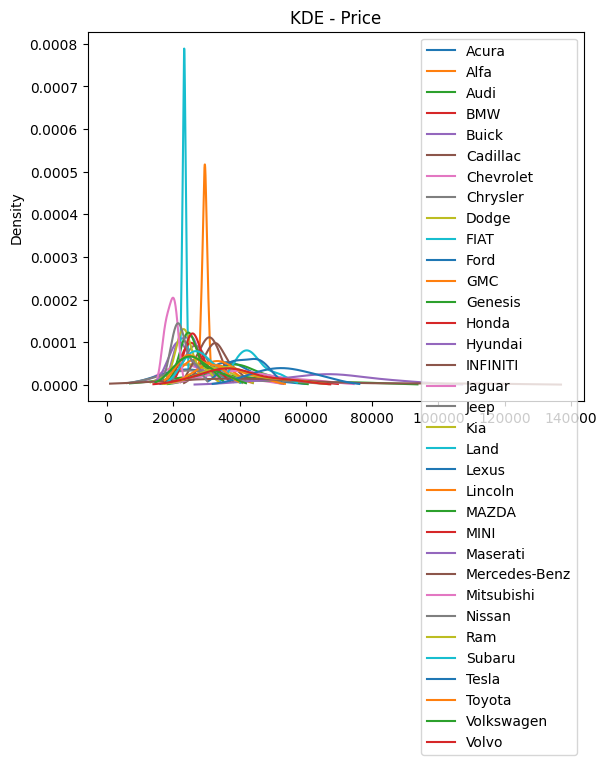

In [254]:
import matplotlib.pyplot as plt

price_data = pivot["Price"].T.fillna(pivot["Price"].T.mean())

plt.figure()
for col in price_data.columns:
    if price_data[col].std() > 0:   # Skip columns with zero variance
        price_data[col].plot.kde(label=col)
    else:
        print(f"Skipping {col} — not enough variation to plot KDE")
plt.title("KDE - Price")
plt.legend()
plt.show()

Skipping Polestar — not enough variation to plot KDE
Skipping Porsche — not enough variation to plot KDE
Skipping smart — not enough variation to plot KDE


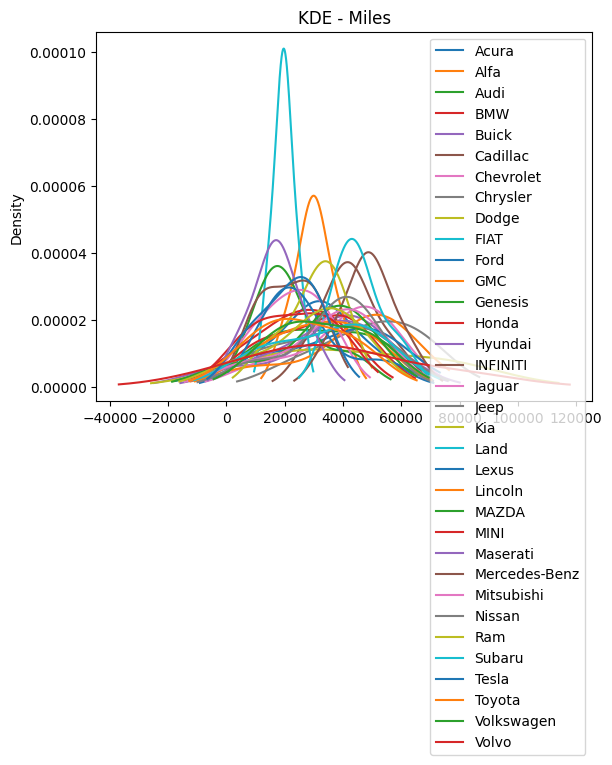

In [255]:
price_data = pivot["Miles"].T.fillna(pivot["Miles"].T.mean())

plt.figure()
for col in price_data.columns:
    if price_data[col].std() > 0:   # zero variance columns skip
        price_data[col].plot.kde(label=col)
    else:
        print(f"Skipping {col} — not enough variation to plot KDE")
plt.title("KDE - Miles")
plt.legend()
plt.show()

### `Question-2:`

You are given a dataset of **Daily Power Generation in India** of regional wise of all Power Stations. Link of the dataset: https://tinyurl.com/2nq6kugt

Task
- In this dataset, there are many columns. Two of them are `Actual(MU)` and `Excess(+) / Shortfall (-)`. `Actual(MU)` represents the actual power generation. `Excess(+) / Shortfall (-)` tells is that generated power is excess or shortfall for that particular day of a power station. You have to find out what should be the actual power generation required for that day by the power stations that there would not be any excess or shorfall power. For the result, make a new column.
- Find out the month of the day and store it as a new column.
- Find out top 10 frequently appeared power stations in this dataframe.
- Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
- It is hard to get inside if you look through the only pivot table. So plot the pivot table.

In [256]:
df2 = pd.read_csv("PowerGeneration.csv")
df2.head()

df2["Dates"] = pd.to_datetime(df2["Dates"])

# Excess = Actual - Required → Required = Actual - Excess
df2["Required(MU)"] = df2["Actual(MU)"] - df2["Excess(+) / Shortfall (-)"]

# Extract the month from the date
df2["Month"] = df2["Dates"].dt.month_name()

# Find the 10 most frequently appearing power stations
top10_stations = df2["Power Station"].value_counts().head(10)
print(top10_stations)

Power Station
NTPC Ltd.    9570
NHPC         5742
NPCIL        5742
GMR ENERG    5742
APL          3828
JPPVL        3828
NLC          3828
JSWEL        3828
TATA PCL     3828
IBPIL        3828
Name: count, dtype: int64


In [257]:
# months in calendar order
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

pivot = df2.pivot_table(index="Power Station", columns="Month", values="Actual(MU)", aggfunc="mean")

# reorder columns Jan -> Dec (only keep months present in data)
pivot = pivot[[m for m in month_order if m in pivot.columns]]

pivot

Month,January,February,March,April,May,June,July,August,September,October,November,December
Power Station,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.925000,NaN,NaN
ABAN POWR,0.870968,0.843972,1.130841,0.600000,0.798387,0.886667,1.058442,0.780645,0.783333,0.945455,0.821229,0.858757
ACB,3.754839,4.397163,4.654206,4.225000,4.290323,4.600000,4.175325,3.812903,3.450000,4.006061,4.480447,4.265537
ACPL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ADHPL,0.000000,0.000000,0.051402,0.608333,1.298387,2.633333,4.194805,3.761290,2.100000,0.945455,0.011173,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
VESPL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
VIP,2.561290,1.191489,1.485981,1.466667,1.491935,1.353333,1.389610,1.006452,3.261111,3.163636,3.083799,3.451977
VVL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


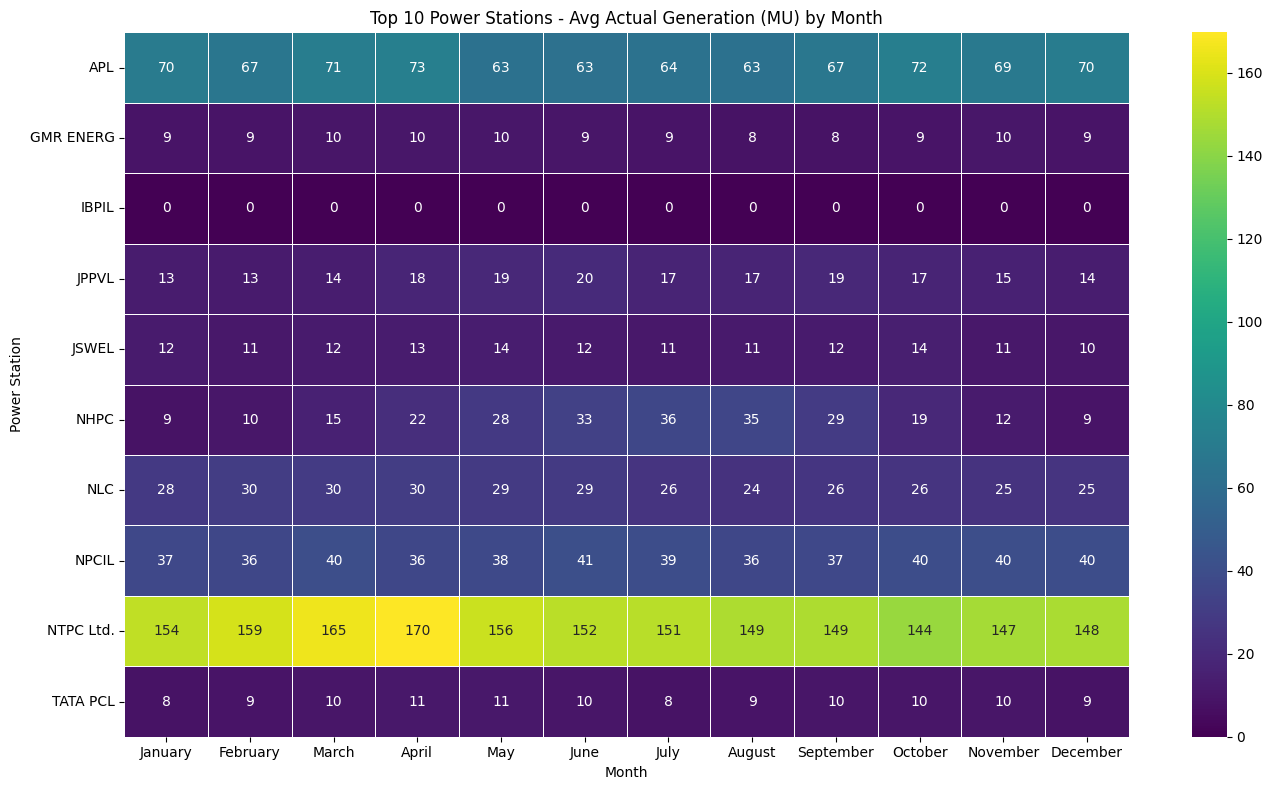

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the top 10 most frequent stations to keep the chart readable
top10_pivot = pivot.loc[pivot.index.isin(top10_stations.index)]

plt.figure(figsize=(14, 8))
sns.heatmap(top10_pivot, cmap="viridis", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Top 10 Power Stations - Avg Actual Generation (MU) by Month")
plt.xlabel("Month")
plt.ylabel("Power Station")
plt.tight_layout()
plt.show()

### `Q-3` You are given a file `question-answer.csv`. Your task is to make a dataframe from it with two columns - `question` and `answers`.

* Questions in the file start from `Q<number>`; E.g.  `Q1` denotes question no. `1`
* Answers starts from `Ans<number>`; Eg. `Ans1` denotes answer of question no `1`
* MAke sure you look at columns name carefully

CSV File - "https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view?usp=share_link"

In [259]:
# Load the data
df3 = pd.read_csv("question-answer.csv", index_col=False)
df3.shape

# Remove the unnecessary index column
df3.drop(columns=["Unnamed: 0"], inplace=True)

# Separate questions and answers
final_df = pd.DataFrame()
final_df["Questions"] = df3["2"].iloc[::2].values
final_df["Answers"] = df3["2"].iloc[1::2].values
final_df

# Remove the question number
final_df["Questions"] = final_df["Questions"].str.split("-", n=1).str.get(1)
final_df["Questions"]

# Remove the answer number
final_df["Answers"] = final_df["Answers"].str.split("-", n=1).str.get(1)
final_df["Answers"]

final_df

,Questions,Answers
0,What is Data Science?,"Data Science combines statistics, maths, speci..."
1,2. How is logistic regression done?,Logistic regression measures the relationship ...
2,How do you build a random forest model?,A random forest is built up of a number of dec...
3,How can you avoid overfitting your model?,Overfitting refers to a model that is only set...
4,You are given a data set consisting of variabl...,The following are ways to handle missing data ...
5,What is bag of words? How we can use it for te...,Bag of Words is a representation of text that ...
6,How can we use machine learning for text class...,Machine learning classification algorithms pre...
7,What is a time series?,A time series is a set of observations ordered...
8,How is time series different from the usual re...,The principle behind causal forecasting is tha...
9,What are the different types of joins? What ar...,(INNER) JOIN: Returns records that have matchi...


### `Q-4`: Print Question and answer of those questions which does not contains any question mark (`?`).


In [260]:
# Find questions that do not end with a question mark
no_question_mark = final_df[~final_df["Questions"].str.endswith("?")]
no_question_mark

,Questions,Answers


### `Q 5-9` LOG and EMPLOYEE
5. Show `activity` details month wise. Show count for each `activity`
6. Find employee who did most `activity` in January month.
7. Employee who have worked most no of times on Weekends.
8. Which activity is logged most on buisness days.
9. Week Days wise activity table.
```
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

```

Note(for common field):- Employee file has `EMPLOYEE_ID` and LOG file has `emp_id`

In [261]:
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

In [262]:
log_file.head()

,Log_ID,dt,dept,emp_id,activity,eqpt
0,1000,2022-01-07,Dept6,115,Cleaning,UPS
1,1001,2022-01-08,Dept4,105,Cleaning,Generator
2,1002,2022-01-09,Dept3,112,Inspection,CPU
3,1003,2022-01-10,Dept4,120,Inspection,UPS
4,1004,2022-01-11,Dept3,138,Checking,Battery


In [263]:
employee.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST


In [264]:
# Q5 Show `activity` details month wise. Show count for each `activity`
# Convert the date column to datetime
log_file["dt"] = pd.to_datetime(log_file["dt"])

# Extract the month name
log_file["Month"] = log_file["dt"].dt.month_name()
log_file.head()

# Count each activity month-wise
pivot_month_wise = log_file.pivot_table(index="Month", columns="activity", values="emp_id", aggfunc="count")
pivot_month_wise

activity,Checking,Cleaning,Inspection,Repair
Month,,,,
April,5,11,9,5
August,8,10,9,4
December,6,7,12,6
February,7,7,4,10
January,7,10,9,5
July,6,6,14,5
June,5,7,8,10
March,8,6,5,12
May,5,8,7,11


In [265]:
# 6. Find employee who did most `activity` in January month.
jan = log_file[log_file["Month"] == "January"]

# Create a full name column
employee["FULL_NAME"] = employee["FIRST_NAME"] + " " + employee["LAST_NAME"]

# Merge January activity data with employee details
final = jan.merge(employee, left_on="emp_id", right_on="EMPLOYEE_ID", how="left")

# Count activities performed by each employee
pivot = final.pivot_table(index="FULL_NAME", values="activity", aggfunc="count")

print(pivot["activity"].idxmax(), pivot["activity"].max())



Payam Kaufling 3


In [266]:
# 7. Employee who have worked most no of times on Weekends.
log_file["Day"] = log_file["dt"].dt.day_name()

# Filter Saturday and Sunday records
weekends = log_file[(log_file["Day"] == "Saturday") | (log_file["Day"] == "Sunday")]

# Merge weekend activity data with employee details
weekends = weekends.merge(employee, left_on="emp_id", right_on="EMPLOYEE_ID", how="left")

# Count weekend activities for each employee
pivot2 = weekends.pivot_table(index="FULL_NAME", values="emp_id", aggfunc="count")

print(pivot2["emp_id"].idxmax(), pivot2["emp_id"].max())

Daniel Faviet 5


In [267]:
# 8. Which activity is logged most on buisness days.
# Find the activity logged most often on business days
bussiness_days = log_file[~((log_file["Day"] == "Saturday") | (log_file["Day"] == "Sunday"))]
bussiness_days.head()

# Count activities using a groupby
# pivot3 = bussiness_days.groupby(["activity"])["activity"].count()

# Count each activity on business days
pivot3 = bussiness_days.pivot_table(index="activity", values="Log_ID", aggfunc="count")

print(pivot3["Log_ID"].idxmax(), pivot3["Log_ID"].max())


Inspection 77


In [268]:
# 9. Week Days wise activity table.

pivot4 = log_file.pivot_table(index="Day", columns="activity", values="Log_ID", aggfunc="count", fill_value=0)

# Arrange weekdays in calendar order
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot4 = pivot4.reindex(order)

print(pivot4)

activity   Checking  Cleaning  Inspection  Repair
Day                                              
Monday           10        14          13      15
Tuesday          15         9          15      13
Wednesday        14         9          13      16
Thursday          8        16          16      12
Friday            8        16          20       9
Saturday         18        11           8      15
Sunday           13        13          15      11


### `Q-10`:

1. There are missing value in first name of employee. Fill it using email and last name field.

> E.g- `email` -> JMURMAN and `last_name` -> 'Urman' -> so make it's first name as 'JM', Sort of (Email- lastname).

> Email is constructed from initials of first name concate with lastname. Your Task is to fill first name initials in missing data.

2. You can see email field don't have any domain name. Change this to full email addreess with domain as 'campusx.com'.
E.g- Email field -> `JMURMAN`  result -> `JMURMAN@CAMPUSX.COM`

3. Show Full Name of all the employees whose name starts with 'A' and has done any of these activity ['Incpection', 'Cleaning', 'Checking]

In [269]:
# 1. Missing first_name ko email aur last_name se fill karna
# Clean whitespace from text columns
employee["FIRST_NAME"] = employee["FIRST_NAME"].str.strip()
employee["LAST_NAME"] = employee["LAST_NAME"].str.strip()
employee["EMAIL"] = employee["EMAIL"].str.strip()

# Fill missing first names using email initials and last name
mask = employee["FIRST_NAME"].isna()

employee.loc[mask, "FIRST_NAME"] = employee.loc[mask].apply(
    lambda row: row["EMAIL"][:len(row["EMAIL"]) - len(row["LAST_NAME"])],
    axis=1
)

In [271]:
# Add the email domain
employee["EMAIL"] = employee["EMAIL"] + "@campusx.com"

# Convert email addresses to uppercase
employee["EMAIL"] = employee["EMAIL"].str.upper()

In [273]:
# Merge January activity data with employee details
final = jan.merge(employee, left_on="emp_id", right_on="EMPLOYEE_ID", how="left")

# Check the exact activity names in the data
print(final["activity"].unique())

<StringArray>
['Cleaning', 'Inspection', 'Checking', 'Repair']
Length: 4, dtype: str


In [274]:
# Find employees whose names start with A and did one of the selected activities
result = final[
    (final["FULL_NAME"].str.startswith("A")) &
    (final["activity"].isin(["Inspection", "Cleaning", "Checking"]))
]["FULL_NAME"].unique().tolist()

print(", ".join(result))

Alexander Khoo


In [275]:
employee.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,FULL_NAME
0,100,Steven,King,SKING@CAMPUSX.COM,Steven King
1,101,Neena,Kochhar,NKOCHHAR@CAMPUSX.COM,Neena Kochhar
2,102,Lex,De Haan,LDEHAAN@CAMPUSX.COM,Lex De Haan
3,103,Alexander,Hunold,AHUNOLD@CAMPUSX.COM,Alexander Hunold
4,104,Bruce,Ernst,BERNST@CAMPUSX.COM,Bruce Ernst
